# Library Imports
Print python / package info and import libraries

In [ ]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.optimizers import Adam

import json
import datetime
import getpass

# Run config (edit before running)
run_config = {
    "run_id": "branch-name:commit-hash",
    "date_time": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "features_used": ["CDHI","CDNI","DHI","DNI","HOUR","TEMPERATURE"],
    "n_features": 6,
    "scaler": "MinMaxScaler",
    "use_pca": False,
    "pca_n_components": None,
    "learning_rate": globals().get("learning_rate", 0.0005),
    "optimizer": "Adam",
    "loss": "mae",
    "epochs": globals().get("setEpoch", 50),
    "batch_size": globals().get("batch_size", 32),
    "lstm_units": [50, 50],
    "seq_len": globals().get("seq_len", 24),
    "validation_split": 0.1,
    "random_seed": 42,
    "user": getpass.getuser(),
    "cwd": os.getcwd()
}

# Print only the key tuning params to keep output tidy
_tune_keys = ["features_used","n_features","learning_rate","optimizer","loss","epochs","batch_size","lstm_units","seq_len","validation_split","random_seed"]
print("Tuning / run config summary:")
print(json.dumps({k: run_config.get(k) for k in _tune_keys}, indent=2))

# Results record (fill after run)
results = {
    "run_id": run_config["run_id"],
    "training_time_s": None,
    "train_loss": None,
    "val_loss": None,
    "test_MAE": None,
    "test_MSE": None,
    "test_RMSE": None,
    "test_R2": None,
    "model_path": os.path.join(os.getcwd(), "Images", "model_run.h5"),
    "plot_path": os.path.join(os.getcwd(), "Images", "pred_plot.png"),
    "notes": ""
}

def save_run_record(run_config, results, out_dir=None):
    out_dir = out_dir or os.path.join(os.getcwd(), "Results")
    os.makedirs(out_dir, exist_ok=True)
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    path = os.path.join(out_dir, f"run_{ts}.json")
    with open(path, "w") as f:
        json.dump({"config": run_config, "results": results}, f, indent=2)
    print("Saved run record to", path)

# New: save a plain-text tuning summary into Images/
def save_tuning_summary(run_config, results, out_dir=None):
    out_dir = out_dir or os.path.join(os.getcwd(), "Images")
    os.makedirs(out_dir, exist_ok=True)
    # include microseconds and MAE for a unique, informative filename
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    mae = results.get("test_MAE")
    mae_tag = f"_mae{mae:.4f}" if mae is not None else ""
    path = os.path.join(out_dir, f"tuning_summary_{ts}{mae_tag}.txt")
    with open(path, "w", encoding="utf-8") as f:
        f.write("Run tuning summary\n")
        f.write("="*48 + "\n\n")
        f.write("Run config:\n")
        f.write(json.dumps(run_config, indent=2))
        f.write("\n\nResults:\n")
        f.write(json.dumps(results, indent=2))
        f.write("\n")
    print("Saved tuning summary to", path)
    return path

# Example usage (fill results then call save_run_record)
# results["training_time_s"] = 123.4
# results["test_MAE"] = mae_value
# save_run_record(run_config, results)

print('Python:', sys.version.splitlines()[0])
print('Executable:', sys.executable)
print('cwd:', os.getcwd())
print('Available CSVs:', glob.glob(os.path.join(os.getcwd(), '*.csv')))

import glob, os
print("Results:", glob.glob(os.path.join(os.getcwd(),"Results","run_*.json")))
print("Images:", glob.glob(os.path.join(os.getcwd(),"Images","*")))


## Parameters

In [ ]:
learning_rate = 0.0005
setEpoch = 50
batch_size = 32

# explicit data folder and csv
data_dir = r"C:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files"
csv_path = os.path.join(data_dir, 'BigData.csv')
assert os.path.isfile(csv_path), f"CSV not found: {csv_path}"
print('Loading dataset:', csv_path)


## Load data

In [ ]:
df = pd.read_csv(csv_path)
df.head()

## Exploratory plots (compact)
Time-series overview, heatmap and boxplots; remove or reduce these later if too many features.

In [35]:
# # quick overview: small figure set
# # These plots give a quick visual overview of the features and their correlations. Currently Commented out. 
# df.plot(subplots=True, figsize=(12, 8), title='Feature Time Series')
# plt.tight_layout()
# #plt.show()

# plt.figure(figsize=(8,6))
# sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
# plt.title('Feature Correlation Heatmap')
# #plt.show()


## Preprocessing: separate target, reshape, normalize

In [36]:
solar_Xdata = df.copy()
solar_ydata = solar_Xdata.pop('POWER')

# convert to numpy arrays (samples x features) and (samples x 1)
solar_Xdata = solar_Xdata.values.reshape(-1, solar_Xdata.shape[1])
solar_ydata = solar_ydata.values.reshape(-1, 1)

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
solar_XdataN = X_scaler.fit_transform(solar_Xdata)
solar_ydataN = y_scaler.fit_transform(solar_ydata)

print('shapes:', solar_XdataN.shape, solar_ydataN.shape)


shapes: (17520, 13) (17520, 1)


## (Optional) PCA placeholder
Keep this cell for later: apply PCA to solar_XdataN when you create the branch that uses PCA.

In [37]:
# Example (commented) - enable later in PCA branch
# n_components = 3
# pca = PCA(n_components=n_components)
# solar_XdataN_pca = pca.fit_transform(solar_XdataN)
# print('explained variance', pca.explained_variance_ratio_)


## Create sequences for LSTM
Using 24 time steps as in your .py file

In [38]:
seq_len = 24
X, y = [], []
for i in range(seq_len, len(solar_ydataN)):
    X.append(solar_XdataN[i-seq_len:i, :])
    y.append(solar_ydataN[i, 0])
X = np.array(X)
y = np.array(y)
print('X shape:', X.shape)
print('y shape:', y.shape)

# split
train_size = int(0.8 * len(y))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print('train/test sizes:', X_train.shape[0], X_test.shape[0])


X shape: (17496, 24, 13)
y shape: (17496,)
train/test sizes: 13996 3500


## Build and train LSTM model

In [39]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=50))
model.add(Dense(units=1))

optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mean_absolute_error')

history = model.fit(X_train, y_train, epochs=setEpoch, batch_size=batch_size, validation_split=0.1)
print('Training finished')


Epoch 1/50


c:\Users\nnaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.1070 - val_loss: 0.0819
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.1070 - val_loss: 0.0819
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0635 - val_loss: 0.0537
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0635 - val_loss: 0.0537
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0544 - val_loss: 0.0572
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0544 - val_loss: 0.0572
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0511 - val_loss: 0.0486
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0511 - val_loss: 0.0486
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0492 - val_loss: 0.0518
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0492 - val_loss: 0.0518
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0478 - val_loss: 0.0472
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step -

## Predict and evaluate

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MAE: 4.184338512682755

Run results summary:
{
  "run_id": "branch-name:commit-hash",
  "training_time_s": null,
  "train_loss": 0.03629586845636368,
  "val_loss": 0.03765314444899559,
  "test_MAE": 4.184338512682755,
  "test_MSE": null,
  "test_RMSE": null,
  "test_R2": null,
  "model_path": "c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\Images\\model_run.h5",
  "plot_path": "c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\Images\\pred_plot.png",
  "notes": ""
}
MAE: 4.184338512682755

Run results summary:
{
  "run_id": "branch-name:commit-hash",
  "training_time_s": null,
  "train_loss": 0.03629586845636368,
  "val_loss": 0.03765314444899559,
  "test_MAE": 4.184338512682755,
  "test_MSE": null,
  "test_RMSE": null,
  "test_R2": null,
  "model_path": "c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA

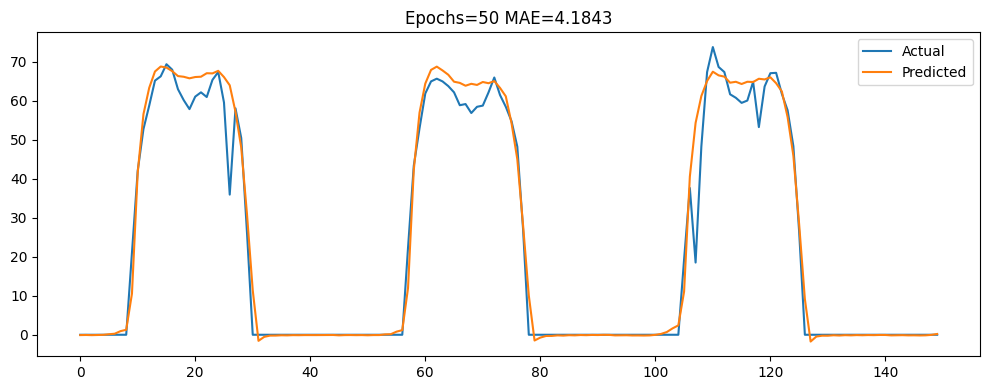

In [40]:
y_pred = model.predict(X_test)
y_pred_orig = y_scaler.inverse_transform(y_pred)
y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1,1))

mae = mean_absolute_error(y_test_orig, y_pred_orig)
print('MAE:', mae)

# populate results dict with values available now
results["train_loss"] = history.history["loss"][-1] if "history" in globals() and "loss" in history.history else results.get("train_loss")
results["val_loss"] = history.history["val_loss"][-1] if "history" in globals() and "val_loss" in history.history else results.get("val_loss")
results["test_MAE"] = float(mae)
results["model_path"] = results.get("model_path")
results["plot_path"] = results.get("plot_path")

# Print results summary
print("\nRun results summary:")
print(json.dumps(results, indent=2))

# Optionally save run record to Results/ (set run_config['auto_save']=True to enable automatic saving)
if run_config.get("auto_save", False):
    save_run_record(run_config, results)

plt.figure(figsize=(10,4))
plt.plot(y_test_orig[:150], label='Actual')
plt.plot(y_pred_orig[:150], label='Predicted')
plt.legend()
plt.title(f'Epochs={setEpoch} MAE={mae:.4f}')
plt.tight_layout()
plt.show()


## Save model outputs / figures

In [41]:
out_dir = os.path.join(os.getcwd(), 'Images')
os.makedirs(out_dir, exist_ok=True)
fig_path = os.path.join(out_dir, f'pred_epoch{setEpoch}_mae{mae:.4f}.png')
plt.figure(figsize=(10,4))
plt.plot(y_test_orig[:150], label='Actual')
plt.plot(y_pred_orig[:150], label='Predicted')
plt.legend()
plt.title(f'Epochs={setEpoch} MAE={mae:.4f}')
plt.tight_layout()
plt.savefig(fig_path)
print('Saved:', fig_path)

# Save the human-readable tuning summary next to the figure
save_tuning_summary(run_config, results, out_dir=out_dir)

plt.close()

Saved: c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files\Images\pred_epoch50_mae4.1843.png
Saved tuning summary to c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files\Images\tuning_summary_20250924_112302.txt
